
# Consolidate MAR/MBR Results

Load Toto and Moirai experiment outputs for the mean-bias study and consolidate them into a single DataFrame.


In [1]:
from pathlib import Path
import os

import pandas as pd


In [2]:
def resolve_repo_root():
    env_root = os.getenv('REPO_ROOT')
    if env_root:
        return Path(env_root)

    search_roots = [Path.cwd(), *Path.cwd().parents]
    for candidate in search_roots:
        if (candidate / 'pyproject.toml').exists():
            return candidate

    raise RuntimeError('Could not determine repository root. Please set the REPO_ROOT environment variable.')

repo_root = resolve_repo_root()
data_root = repo_root / 'results_shared/01_mean-bias'
model_dirs = {
    'Toto': data_root / '02_toto',
    'Moirai': data_root / '03_moirai',
}
terms = ('short', 'medium', 'long')
exclude_columns = {'dataset', 'variate', 'num_variates', 'model', 'dataset_slug'}

frames = []
missing_files = []

for model_name, model_path in model_dirs.items():
    for term in terms:
        csv_path = model_path / f"{model_name.lower()}_{term}.csv"
        if not csv_path.exists():
            missing_files.append(csv_path)
            continue

        df = pd.read_csv(csv_path)

        metric_cols = [
            col for col in df.columns
            if col not in exclude_columns
            and not col.lower().startswith('unnamed')
        ]

        tidy = df[['dataset', *metric_cols]].copy()
        tidy.insert(1, 'term', term)
        tidy.insert(2, 'model', model_name)
        frames.append(tidy)

if missing_files:
    print('Missing files:')
    for missing in missing_files:
        print(' -', missing)


In [4]:
for i, df in enumerate(frames):
    frames[i] = df.copy()
    frames[i]['dataset'] = frames[i]['dataset'].str.rsplit('/', n=1).str[0]

In [5]:
consolidated = pd.concat(frames, ignore_index=True)

In [6]:
consolidated.columns

Index(['dataset', 'term', 'model', 'eval_metrics/MAR[0.5][512]',
       'eval_metrics/MBR[0.5][512]', 'eval_metrics/MSE[mean]',
       'eval_metrics/MSE[0.5]', 'eval_metrics/MAE[0.5]',
       'eval_metrics/MASE[0.5]', 'eval_metrics/MAPE[0.5]',
       'eval_metrics/sMAPE[0.5]', 'eval_metrics/MSIS',
       'eval_metrics/RMSE[mean]', 'eval_metrics/NRMSE[mean]',
       'eval_metrics/ND[0.5]', 'eval_metrics/mean_weighted_sum_quantile_loss'],
      dtype='object')

In [7]:
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt
def plot_bar(term, model, metric, consolidated=consolidated, y_range=None, add_lines=None):
    """
    Plots a bar chart for the specified term, model, and metric.
    Optionally limits the y-axis range if y_range is provided.
    Optionally adds horizontal lines for each value in add_lines.
    """
    if metric.lower() == 'mar':
        metric_col = "eval_metrics/MAR[0.5][512]"
        ref_value = 1.0
        ref_label = 'Reference: 1.0'
    elif metric.lower() == 'mbr':
        metric_col = "eval_metrics/MBR[0.5][512]"
        ref_value = 0.5
        ref_label = 'Reference: 0.5'
    else:
        metric_col = metric
        ref_value = None

    subset = consolidated[(consolidated['term'] == term) & (consolidated['model'] == model)]
    plt.figure(figsize=(12, 6))
    plt.bar(subset['dataset'], subset[metric_col])
    plt.xticks(rotation=90)
    plt.ylabel(metric_col)
    plt.title(f'{model} - {term} - {metric_col}')
    plt.tight_layout()
    if y_range is not None:
        plt.ylim(y_range)
    legend_elements = []
    if ref_value is not None:
        plt.axhline(ref_value, color='red', linestyle='--', linewidth=1)
        legend_elements.append(Line2D([0], [0], color='red', lw=1, linestyle='--', label=ref_label))
    if add_lines is not None:
        for v in add_lines:
            plt.axhline(v, color='gray', linestyle=':', linewidth=1)
            legend_elements.append(Line2D([0], [0], color='gray', lw=1, linestyle=':', label=f'Line: {v}'))
    if legend_elements:
        plt.legend(handles=legend_elements)
    plt.show()
    


In [8]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt

def plot_all(metric, consolidated=consolidated, y_range=None, add_lines=None, models=None, terms=None):
    """
    Plot all datasets for a given metric, grouped by dataset.
    Per dataset: groups by model (Toto, Moirai), each with 3 bars (short, medium, long).
    
    Supports:
      - default horizontal reference line for MAR/MBR
      - optional y_range
      - optional add_lines
      - optional filters: models=['Toto'], terms=['short','long']
      
    Example usage:
      plot_all(metric='MAR', y_range=(0.7, 2), models=['Toto', 'Moirai'], terms=['short', 'medium', 'long'])
      plot_all(metric='MBR', y_range=(0.4, 0.8), add_lines=[0.6], terms=['short', 'long'])
    """
    # Resolve metric column and default reference line
    if isinstance(metric, str) and metric.lower() == 'mar':
        metric_col = "eval_metrics/MAR[0.5][512]"
        ref_value = 1.0
        ref_label = 'Reference: 1.0'
    elif isinstance(metric, str) and metric.lower() == 'mbr':
        metric_col = "eval_metrics/MBR[0.5][512]"
        ref_value = 0.5
        ref_label = 'Reference: 0.5'
    else:
        metric_col = metric
        ref_value = None
        ref_label = None

    # Ensure required columns exist
    required_cols = {'dataset', 'model', 'term', metric_col}
    missing = required_cols - set(consolidated.columns)
    if missing:
        raise ValueError(f"Missing required columns in consolidated DataFrame: {missing}")

    # Determine available and selected models/terms
    all_models_pref = ['Toto', 'Moirai']
    available_models = [m for m in all_models_pref if m in consolidated['model'].unique()]
    selected_models = available_models if models is None else [m for m in models if m in available_models]
    if not selected_models:
        raise ValueError(f"No matching models found. Available: {available_models}, requested: {models}")

    all_terms_pref = ['short', 'medium', 'long']
    available_terms = [t for t in all_terms_pref if t in consolidated['term'].unique()]
    selected_terms = available_terms if terms is None else [t for t in terms if t in available_terms]
    if not selected_terms:
        raise ValueError(f"No matching terms found. Available: {available_terms}, requested: {terms}")

    # All datasets (always include all)
    datasets = sorted(consolidated['dataset'].unique())

    # Colors by term and hatches by model
    term_colors = {
        'short': '#1f77b4',   # blue
        'medium': '#ff7f0e',  # orange
        'long': '#2ca02c',    # green
    }
    default_color = '#7f7f7f'
    model_hatch = {
        'Toto': '',
        'Moirai': '//',
    }

    # Geometry for grouped bars (adapts to counts)
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    x = np.arange(len(datasets))  # dataset positions
    n_models = len(selected_models)
    n_terms = len(selected_terms)

    inner_gap = 0.08  # gap between model groups within a dataset
    usable_width = 0.8
    bar_width = (usable_width - inner_gap * max(0, n_models - 1)) / (n_models * n_terms)
    total_width = n_models * n_terms * bar_width + inner_gap * max(0, n_models - 1)

    def positions_for_dataset(x_i):
        left = x_i - total_width / 2.0
        centers = []
        for m_idx in range(n_models):
            for t_idx in range(n_terms):
                j = m_idx * n_terms + t_idx
                extra = m_idx * inner_gap
                center = left + j * bar_width + extra + bar_width / 2.0
                centers.append(center)
        return centers  # length n_models * n_terms

    # Build a quick lookup for metric values
    df_vals = (consolidated[['dataset', 'model', 'term', metric_col]]
               .drop_duplicates(subset=['dataset', 'model', 'term'], keep='first'))

    def get_value(dataset, model, term):
        sel = df_vals[(df_vals['dataset'] == dataset) &
                      (df_vals['model'] == model) &
                      (df_vals['term'] == term)]
        if len(sel) == 0:
            return np.nan
        return float(sel[metric_col].iloc[0])

    plt.figure(figsize=(max(12, len(datasets) * 0.6), 6))

    # Plot bars
    for i, d in enumerate(datasets):
        centers = positions_for_dataset(x[i])
        idx = 0
        for m_idx, model in enumerate(selected_models):
            for t_idx, term in enumerate(selected_terms):
                height = get_value(d, model, term)
                color = term_colors.get(term, default_color)
                hatch = model_hatch.get(model, '')
                plt.bar(centers[idx], height, width=bar_width, color=color, hatch=hatch,
                        edgecolor='black', linewidth=0.4)
                idx += 1

    # X-axis labels (datasets)
    plt.xticks(x, datasets, rotation=90)
    plt.ylabel(metric_col)
    plt.title(f'All datasets - {metric_col}')
    plt.tight_layout()

    # y-range
    if y_range is not None:
        plt.ylim(y_range)

    # Reference and extra lines
    legend_elements = []
    if ref_value is not None:
        plt.axhline(ref_value, color='red', linestyle='--', linewidth=1)
        legend_elements.append(Line2D([0], [0], color='red', lw=1, linestyle='--', label=ref_label))
    if add_lines is not None:
        for v in add_lines:
            plt.axhline(v, color='gray', linestyle=':', linewidth=1)
            legend_elements.append(Line2D([0], [0], color='gray', lw=1, linestyle=':', label=f'Line: {v}'))

    # Legends for terms (colors) and models (hatches)
    term_patches = [Patch(facecolor=term_colors.get(t, default_color), edgecolor='black', label=f'Term: {t}')
                    for t in selected_terms]
    model_patches = [Patch(facecolor='white', edgecolor='black', hatch=model_hatch.get(m, ''), label=f'Model: {m}')
                     for m in selected_models]

    handles = term_patches + model_patches + legend_elements
    if handles:
        plt.legend(handles=handles, loc='best')

    plt.show()



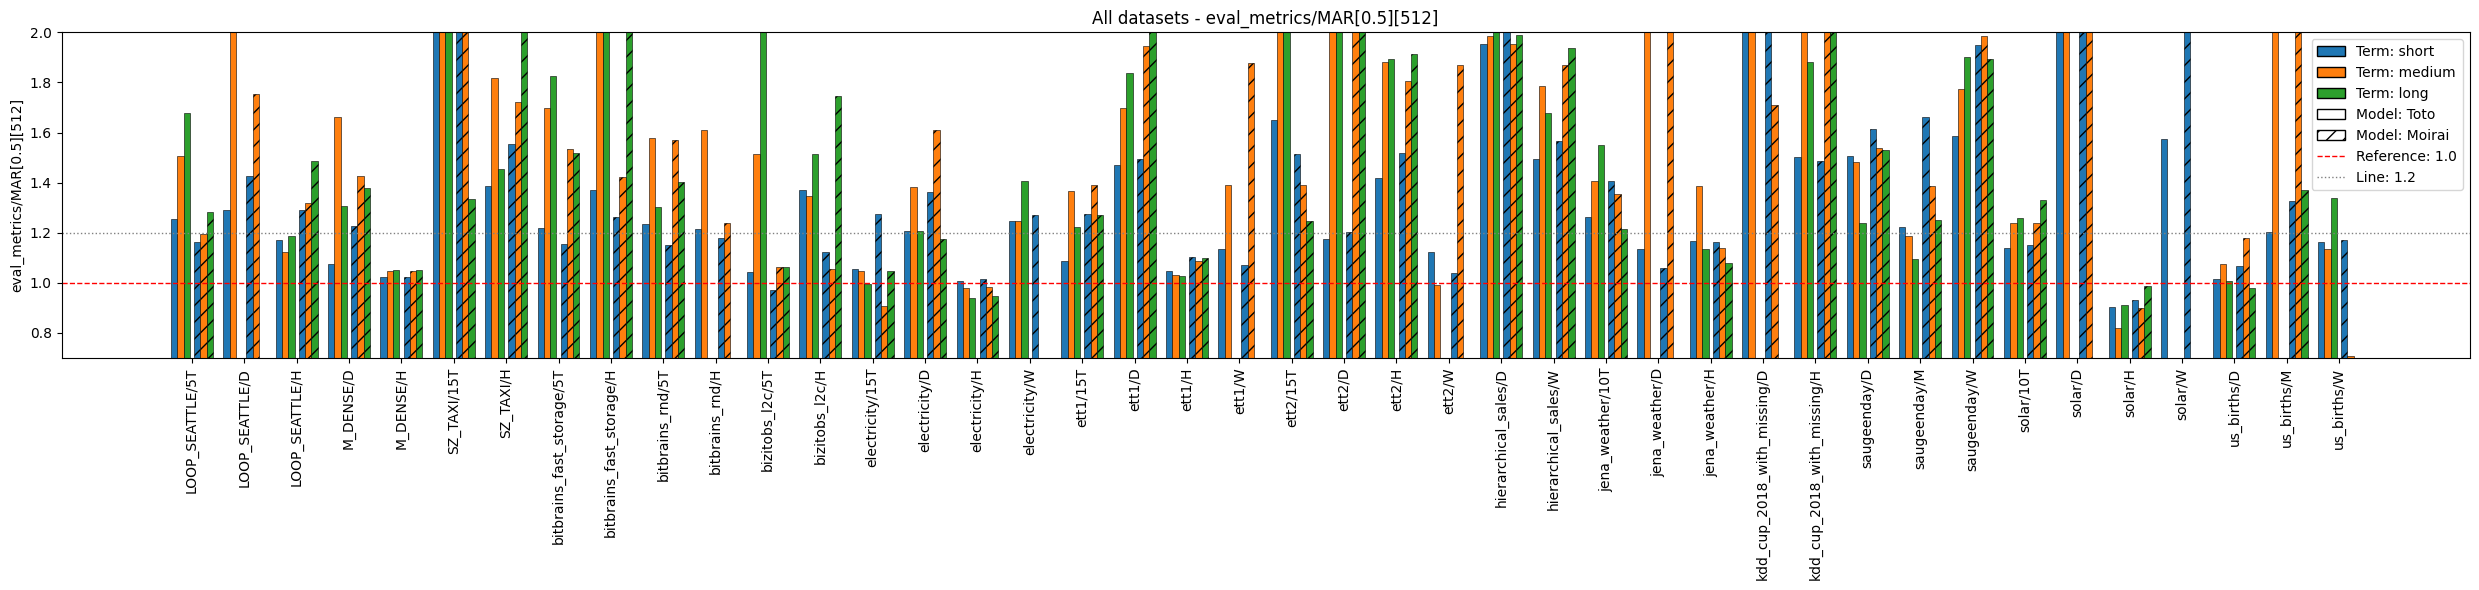

In [9]:
plot_all(metric='MAR', y_range=(0.7, 2), models=['Toto', 'Moirai'], terms=['short', 'medium', 'long'], add_lines=[1.2])

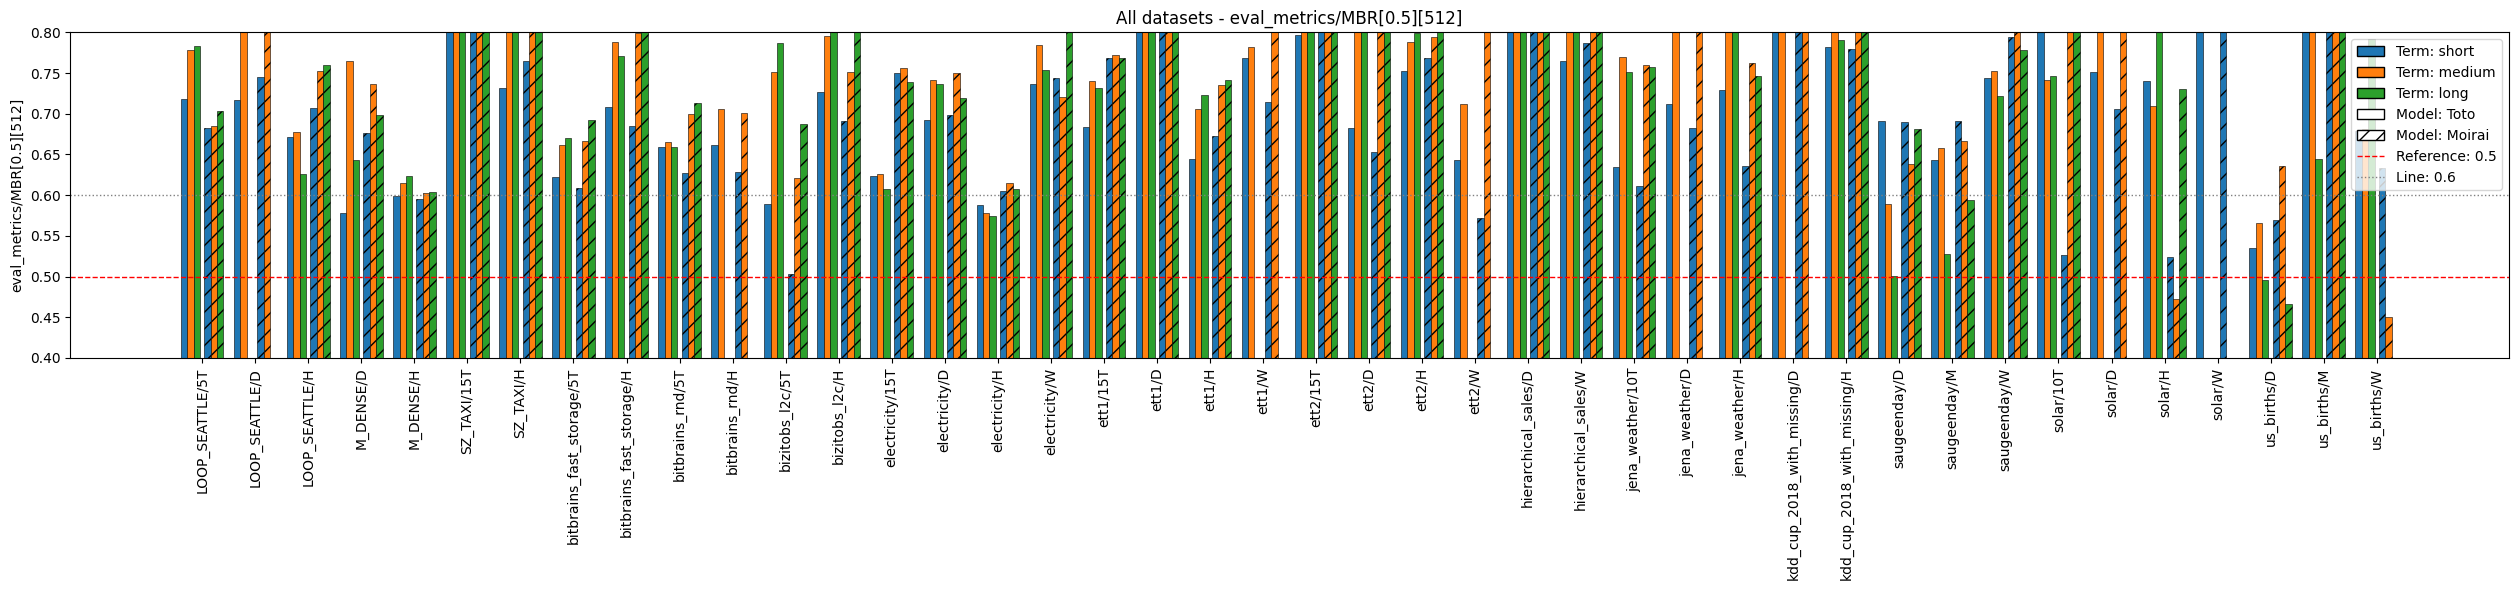

In [10]:
plot_all(metric='MBR', y_range=(0.4, 0.8), models=['Toto', 'Moirai'], terms=['short', 'medium', 'long'], add_lines=[0.6])